# Unrestricted Hartree Fock Challenges
This notebook will exemplify some issues in the development of the UHF and what/how fixes were implemented.

In [1]:
from pyscf import gto, scf
import numpy as np
from py_mods.src.SCF.CSUHF import CS_UHF
from py_mods.src.SCF.types import CSUHFContext
from py_mods.src.SCF.plot_utilities import plot_map
import matplotlib.pyplot as plt

## Incorrect Li SCF convergence
This example shows how a flawed guess can lead to errors. In this particular case, with a $H_{core}$ guess, the DIIS gets stuck in an incorrect minimum, and converges to a wrong state. However, if we let the regular SCF continue direvtly it bounces to the correct minimum.

In [2]:
# pyscf data
mol_He = gto.M(atom="  Li 0 0 0; ", spin=1, charge=0, basis="aug-cc-pvqz")

kin = mol_He.intor("int1e_kin")
vnuc = mol_He.intor("int1e_nuc")
overlap = mol_He.intor("int1e_ovlp")
eri = mol_He.intor("int2e")

rhf_He = scf.UHF(mol_He)

e_He = rhf_He.kernel()
e_elec = rhf_He.energy_elec()

print(e_elec)

converged SCF energy = -7.43271871704646  <S^2> = 0.75001472  2S+1 = 2.0000147
(np.float64(-7.4327187170464555), np.float64(2.2810037415636373))


In [3]:
# Preparation of the context and calculation
Li_context = CSUHFContext(overlap, kin, vnuc, eri, n_electrons=3)
Li_context.max_iter = 300
Li_context.conv_type = "DIIS"
Li_context.p_guess = "core"
Li_context.verbose = True
Li_context.threshold = 1e-12

In [4]:
# Li_UHF_results = CS_UHF(Li_context)
# print(f"Converged: {Li_UHF_results.converged} in {Li_UHF_results.iterations}")
# print(f"Final energy: {Li_UHF_results.E_UHF}")
# print(f"Error in Final energy: {Li_UHF_results.E_UHF-e_elec[0]}")

Which is not correct, as it has converged to an incorrect minimum. To fix this problem, we have introduced a RHF guess, that generates a RHF of this system or the cation (to have even electrons) and then starts the UHF calculation from this density:

In [5]:
# Li_context.p_guess = "RHF"
# Li_correct_UHF_results = CS_UHF(Li_context)
# print(
#     f"Converged: {Li_correct_UHF_results.converged} in {Li_correct_UHF_results.iterations}"
# )
# print(f"Final energy: {Li_correct_UHF_results.E_UHF}")
# print(f"Error in Final energy: {Li_correct_UHF_results.E_UHF-e_elec[0]}")

# Dissociations 
A simple dissociation. Chose atoms, basis and number of electrons here:  

In [6]:
# change here to see different curves.
n_points = 20
element_1 = "H"
element_2 = "H"
basis = "aug-cc-pvdz"
n_elec = 2
distances = np.linspace(0.3, 20, n_points)

In [7]:
RHF_eners = np.zeros_like(distances)
for i, dist in enumerate(distances):
    mol_He = gto.M(
        atom=f"  {element_1} 0 0 0; {element_2} {dist} 0 0",
        spin=0,
        charge=0,
        basis=basis,
    )

    kin = mol_He.intor("int1e_kin")
    vnuc = mol_He.intor("int1e_nuc")
    overlap = mol_He.intor("int1e_ovlp")
    eri = mol_He.intor("int2e")

    rhf_He = scf.RHF(mol_He)

    e_He = rhf_He.kernel()
    e_elec = rhf_He.energy_elec()

    RHF_eners[i] = e_elec[0]

converged SCF energy = -0.615684850088791
converged SCF energy = -1.034676710594
converged SCF energy = -0.882297779032788
converged SCF energy = -0.811975886752774
converged SCF energy = -0.780100230049185
converged SCF energy = -0.764396588008338
converged SCF energy = -0.755339650653042
converged SCF energy = -0.749329233917382
converged SCF energy = -0.744969142613482
converged SCF energy = -0.74161765538248
converged SCF energy = -0.738937048270004
converged SCF energy = -0.736735556926881
converged SCF energy = -0.734893465665011
converged SCF energy = -0.733329179442761
converged SCF energy = -0.73198434841722
converged SCF energy = -0.730815614332611
converged SCF energy = -0.729790507428409
converged SCF energy = -0.728884060780312
converged SCF energy = -0.728076787738913
converged SCF energy = -0.727353251418969


In [8]:
UHF_eners = np.zeros_like(distances)
for i, dist in enumerate(distances):
    mol = gto.M(
        atom=f"  {element_1} 0 0 0; {element_2} {dist} 0 0",
        spin=0,
        charge=0,
        basis=basis,
    )

    mf = scf.UHF(
        mol,
    )

    dm_alpha, dm_beta = mf.get_init_guess()

    e_He = mf.kernel()
    e_elec = mf.energy_elec()

    UHF_eners[i] = e_elec[0]

converged SCF energy = -0.615684850089086  <S^2> = 6.6613381e-16  2S+1 = 1
converged SCF energy = -1.03467671059411  <S^2> = 3.7392311e-13  2S+1 = 1
converged SCF energy = -0.882297779010254  <S^2> = 1.474294e-10  2S+1 = 1
converged SCF energy = -0.811975886750827  <S^2> = 1.8794077e-11  2S+1 = 1
converged SCF energy = -0.78010023004898  <S^2> = 2.3128166e-12  2S+1 = 1
converged SCF energy = -0.764396588008213  <S^2> = 1.4417356e-12  2S+1 = 1
converged SCF energy = -0.755339650652872  <S^2> = 1.8960389e-12  2S+1 = 1
converged SCF energy = -0.749329233917342  <S^2> = 4.5030646e-13  2S+1 = 1
converged SCF energy = -0.744969142613488  <S^2> = 2.5157654e-13  2S+1 = 1
converged SCF energy = -0.741617655389945  <S^2> = 2.3230085e-11  2S+1 = 1
converged SCF energy = -0.73893704913218  <S^2> = 2.8874652e-09  2S+1 = 1
converged SCF energy = -0.73673555767167  <S^2> = 1.2235768e-11  2S+1 = 1
converged SCF energy = -0.734893485213894  <S^2> = 5.0595141e-08  2S+1 = 1.0000001
converged SCF energy =

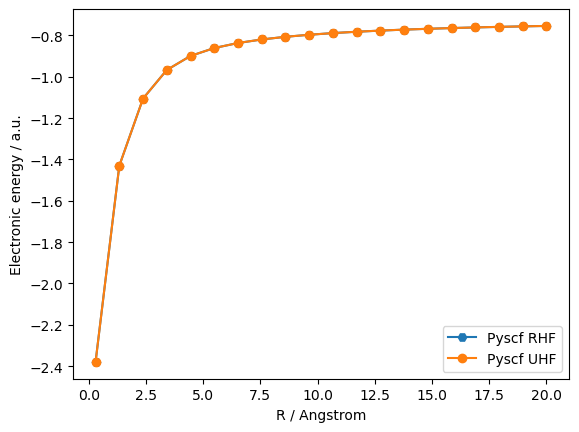

In [9]:
plt.plot(distances, RHF_eners, label="Pyscf RHF", marker="H")
plt.plot(distances, UHF_eners, label="Pyscf UHF", marker="o")
plt.xlabel("R / Angstrom")
plt.ylabel("Electronic energy / a.u.")
plt.legend()
plt.show()

And we can see that there is no notable difference. This is because it is necessary to break the symmetry of the alpha and beta density matrices. This is done by setting to zero the beta density of the 1s and 2s orbitals in the H case. 

In [10]:
UHF_eners = np.zeros_like(distances)
for i, dist in enumerate(distances):
    mol = gto.M(
        atom=f"  {element_1} 0 0 0; {element_2} {dist} 0 0",
        spin=0,
        charge=0,
        basis=basis,
    )

    kin = mol_He.intor("int1e_kin")
    vnuc = mol_He.intor("int1e_nuc")
    overlap = mol_He.intor("int1e_ovlp")
    eri = mol_He.intor("int2e")

    mf = scf.UHF(
        mol,
    )

    dm_alpha, dm_beta = mf.get_init_guess()
    dm_beta[:n_elec, :n_elec] = 0
    dm = (dm_alpha, dm_beta)

    e_He = mf.kernel(
        dm,
    )
    e_elec = mf.energy_elec()

    UHF_eners[i] = e_elec[0]

converged SCF energy = -0.615684850088439  <S^2> = 1.5798474e-12  2S+1 = 1
converged SCF energy = -1.03864784386918  <S^2> = 0.30489089  2S+1 = 1.48982
converged SCF energy = -0.999887797154762  <S^2> = 0.96713035  2S+1 = 2.2064726
converged SCF energy = -0.998708631970888  <S^2> = 0.99843331  2S+1 = 2.2346662
converged SCF energy = -0.998671476308304  <S^2> = 0.9999332  2S+1 = 2.2360082
converged SCF energy = -0.9986688652494  <S^2> = 0.99999754  2S+1 = 2.2360658
converged SCF energy = -0.998668684804258  <S^2> = 0.99999991  2S+1 = 2.2360679
converged SCF energy = -0.998668637778935  <S^2> = 1  2S+1 = 2.236068
converged SCF energy = -0.998668635576205  <S^2> = 1  2S+1 = 2.236068
converged SCF energy = -0.99866863254733  <S^2> = 1  2S+1 = 2.236068
converged SCF energy = -0.998668631169543  <S^2> = 1  2S+1 = 2.236068
converged SCF energy = -0.998668630908914  <S^2> = 1  2S+1 = 2.236068
converged SCF energy = -0.998668630881102  <S^2> = 1  2S+1 = 2.236068
converged SCF energy = -0.998668

And we can see that there is a difference in the dissociation curve, as one would expect in the unrestricted case. 

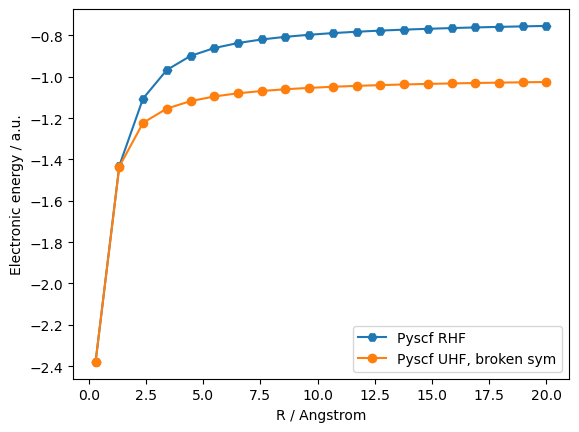

In [11]:
plt.plot(distances, RHF_eners, label="Pyscf RHF", marker="H")
plt.plot(distances, UHF_eners, label="Pyscf UHF, broken sym", marker="o")
plt.xlabel("R / Angstrom")
plt.ylabel("Electronic energy / a.u.")
plt.legend()
plt.show()

However, up to now, the guess for the SCF has been to use the core Hamiltonian. Using this approach directly results in no symmetry breaking, as the density matrix is composed of zeros in the guess. 

Therefore, in order to be able to break the symmetry, it is necessary a non-zero guess. In the current implementation here, we combine the RHF and UHF to start with a few iterations of the RHF in order to get a better guess of the density and then start the UHF loop from this density. 

We will compare now the densities between the pyscf formulation and this approach. 

converged SCF energy = -0.998668631839391  <S^2> = 1  2S+1 = 2.236068


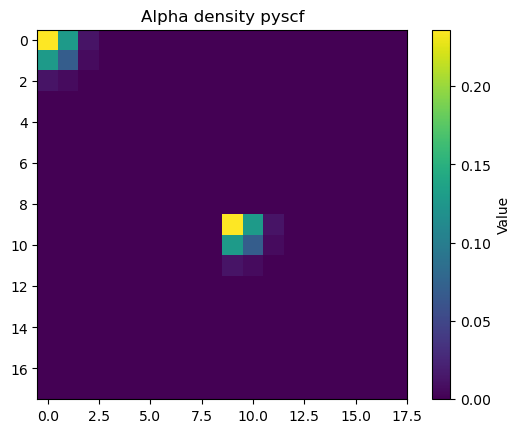

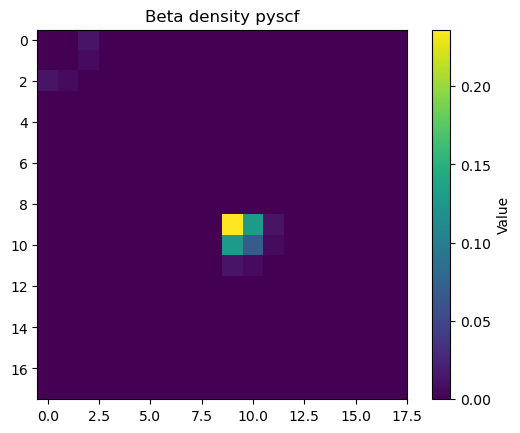

In [12]:
mol = gto.M(
    atom=f"  {element_1} 0 0 0; {element_2} 10 0 0",
    spin=0,
    charge=0,
    basis=basis,
)

kin = mol.intor("int1e_kin")
vnuc = mol.intor("int1e_nuc")
overlap = mol.intor("int1e_ovlp")
eri = mol.intor("int2e")


mf = scf.UHF(
    mol,
)

dm_alpha, dm_beta = mf.get_init_guess()
dm_beta[:n_elec, :n_elec] = 0

dm = (dm_alpha, dm_beta)
mf.kernel(dm)

plot_map(dm_alpha, title="Alpha density pyscf")
plot_map(dm_beta, title="Beta density pyscf")

With the regular core guess

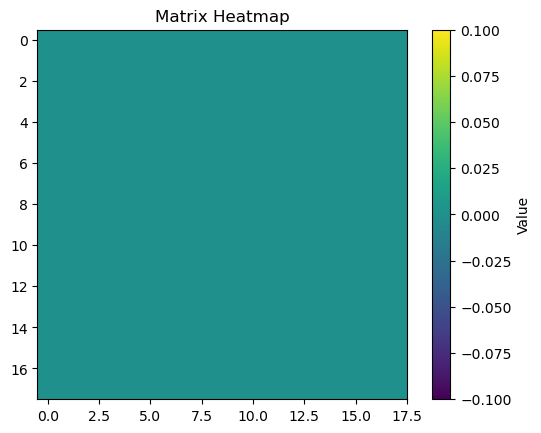

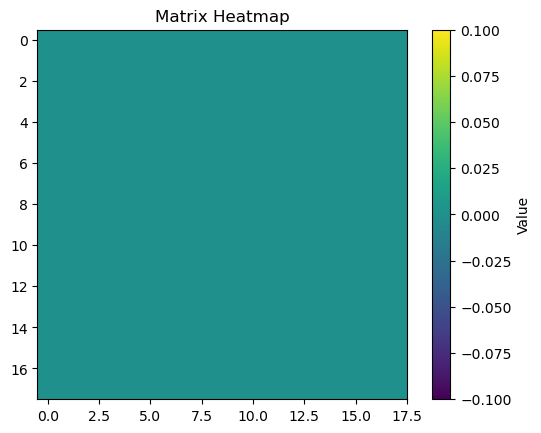

In [13]:
context = CSUHFContext(overlap, kin, vnuc, eri, n_electrons=n_elec, max_iter=1)

CS_UHF_results = CS_UHF(context)

plot_map(CS_UHF_results.P_guess_alpha.real)
plot_map(CS_UHF_results.P_guess_beta.real)

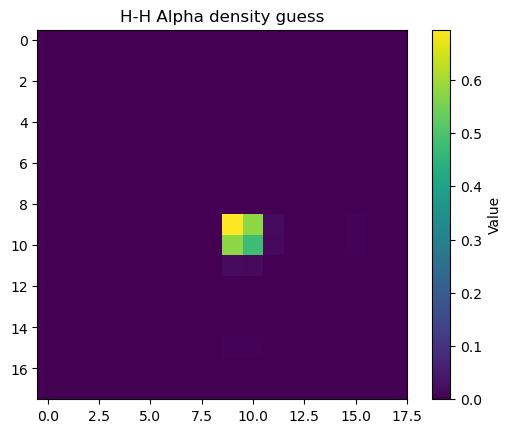

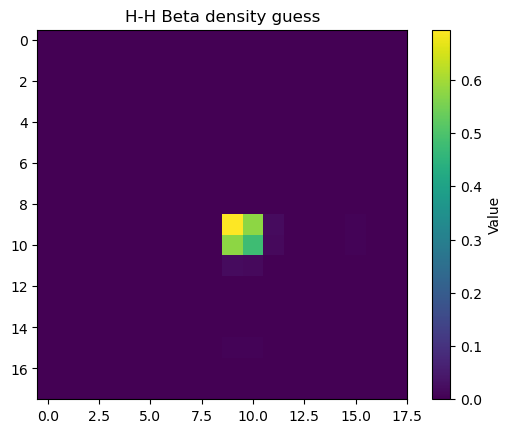

In [14]:
context = CSUHFContext(
    overlap,
    kin,
    vnuc,
    eri,
    n_electrons=n_elec,
    break_symm=True,
    max_iter=50,
    p_guess="RHF",
)

CS_UHF_results = CS_UHF(context)

plot_map(
    CS_UHF_results.P_guess_alpha.real,
    title=f"{element_1}-{element_2} Alpha density guess",
)
plot_map(
    CS_UHF_results.P_guess_beta.real,
    title=f"{element_1}-{element_2} Beta density guess",
)

And the final densities:

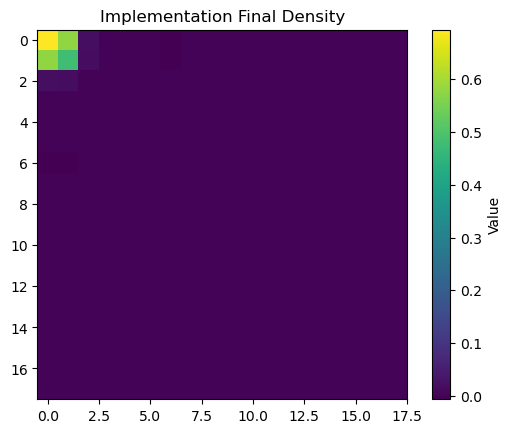

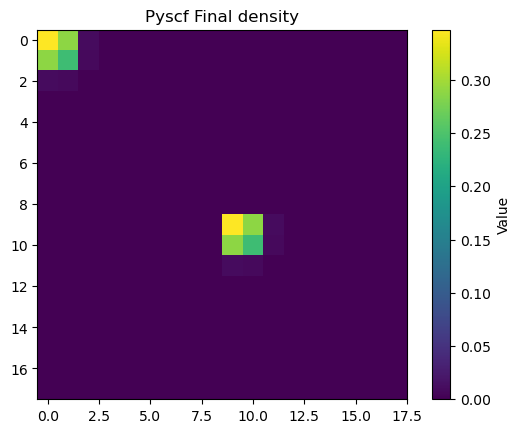

2.0000000000000004
1.9999999999999998


In [15]:
plot_map(CS_UHF_results.P_total.real, title="Implementation Final Density")
plot_map(mf.make_rdm1()[0] + mf.make_rdm1()[1], title="Pyscf Final density")
print(np.trace(CS_UHF_results.P_total.real @ CS_UHF_results.context.S))
print(np.trace((mf.make_rdm1()[0] + mf.make_rdm1()[1]) @ CS_UHF_results.context.S))

## Final dissociation curves
Here we can see the final dissociation curves using this `guess+bsymm` approach. It can be seen that even though in cases such as $HF$ the results are different to the pyscf ones, in both cases convergence is not achieved at longer distances. However, while pyscf seems to oscillate between the RHF and UHF, the implemented UHF presents the expected UHF tendency (even though it is not converged at these points).

In [16]:
Imp_RHF_eners = np.zeros_like(distances)
Imp_RHF_eners_core_guess = np.zeros_like(distances)

for i, dist in enumerate(distances):
    mol = gto.M(
        atom=f"  {element_1} 0 0 0; {element_2} {dist} 0 0",
        spin=0,
        charge=0,
        basis=basis,
    )

    kin = mol.intor("int1e_kin")
    vnuc = mol.intor("int1e_nuc")
    overlap = mol.intor("int1e_ovlp")
    eri = mol.intor("int2e")

    context = CSUHFContext(
        overlap,
        kin,
        vnuc,
        eri,
        n_electrons=n_elec,
        p_guess="RHF",
        break_symm=True,
        max_iter=200,
        _eigensolver = 'eigh'
    )

    try:
        CS_UHF_results = CS_UHF(context)
        print({dist}, CS_UHF_results.converged)
        Imp_RHF_eners[i] = CS_UHF_results.E_UHF.real
    
    except RuntimeError:
        pass

{np.float64(0.3)} True
{np.float64(1.3368421052631578)} True
{np.float64(2.3736842105263154)} True
{np.float64(3.410526315789473)} True
{np.float64(4.447368421052631)} True
{np.float64(5.484210526315789)} True
{np.float64(6.5210526315789465)} True
{np.float64(7.557894736842104)} True
{np.float64(8.594736842105263)} True
{np.float64(10.66842105263158)} True
{np.float64(12.742105263157894)} True
{np.float64(14.815789473684209)} True
{np.float64(15.852631578947367)} True
{np.float64(16.889473684210525)} True
{np.float64(17.926315789473684)} True
{np.float64(18.96315789473684)} True


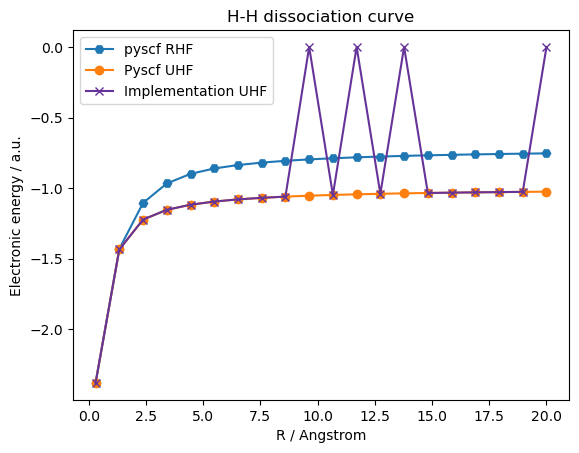

In [17]:
plt.plot(distances, RHF_eners, label="pyscf RHF", marker="H")
plt.plot(distances, UHF_eners, label="Pyscf UHF", marker="o")
plt.plot(
    distances, Imp_RHF_eners, label="Implementation UHF", marker="x", c="rebeccapurple"
)
plt.title(f"{element_1}-{element_2} dissociation curve")
plt.xlabel("R / Angstrom")
plt.ylabel("Electronic energy / a.u.")
plt.legend()
plt.show()

In [18]:
print(repr(UHF_eners))

array([-2.37960889, -1.43448906, -1.22282276, -1.15386862, -1.11765807,
       -1.09515991, -1.07981773, -1.06868512, -1.06023855, -1.05361053,
       -1.04827084, -1.04387712, -1.04019844, -1.03707339, -1.03438574,
       -1.03204966, -1.03000041, -1.02818821, -1.02657417, -1.02512749])
